## **Summary**
This notebook demonstrates a perturbation prediction framework with model training, including:
1. Loading TF–target interaction and RNA-seq datasets.
2. Aligning datasets and extracting common mRNAs.
3. Reducing perturbation embeddings with PCA.
4. Training a predictive model via cross-validation.
5. Evaluating predictions against actual perturbation responses.

## **Importing required packages**

In [1]:
import scanpy as sc
import tfactprofiler as tfp
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading TF–Target interaction data and RNA-seq dataset**
This repository includes curated priors that encode transcription factor–to–mRNA relationships. The file, TFactprofiler_all.csv, aggregates interactions learned from a diverse collection of organs and cell types. This makes it the recommended default when broad generalizability across tissues is desired. For studies that require tissue- or cell-type-specificity, the tfact_organ directory provides models that were trained separately using data from each organ or cell type. You can select the file named after the organ of interest to bias the inference toward that context. All files consist of a transcription factor (source), target, and an interaction weight. One practical approach is to start with the TFactprofiler_all.csv file to establish a baseline. Then, if needed, repeat the analysis with the organ-specific file to assess tissue-specific effects or prioritize regulatory edges enriched in the focal context.

In [ ]:
#load prior knowledge including TF-target interactions
tfactprofiler_data=pd.read_csv("TFactprofiler_all.csv")
P = tfactprofiler_data.pivot_table(index="source", columns="target", values="weight", aggfunc="mean", fill_value=0)
P = pd.DataFrame(P.values,index=P.index.values, columns=P.columns.values)
P = P.T

# Load KO data
# The data comes from Replogle,J.M., Saunders,R.A., Pogson,A.N., Hussmann,J.A., Lenail,A., Guna,A., Mascibroda,L., Wagner,E.J., Adelman,K., Lithwick-Yanai,G., et al. (2022) Mapping information-rich genotype-phenotype landscapes with genome-scale Perturb-seq. Cell, 185, 2559-2575.e28.
adata= sc.read_h5ad(filename="Raplogle_K562_bulk.h5ad")
adata = adata[adata.obs['fold_expr'] < 1].copy()
non_duplicate_mask = ~adata.var["gene_name"].duplicated()
adata = adata[:, non_duplicate_mask].copy()
A=adata.obs.reset_index()
split_cols = A['gene_transcript'].str.split('_', expand=True)
split_cols.columns = ['gene_id', 'gene_symbol', 'transcript_variant', 'ensembl_id']
A = pd.concat([split_cols, A], axis=1)
A=pd.DataFrame(A["gene_symbol"])
A["type_p"]=-1
A.rename(columns={"gene_symbol": 'source'}, inplace=True)
adata.obs=A
adata.var = pd.DataFrame(index=adata.var["gene_name"].values)
adata.var.index.name = None
Y=pd.DataFrame(adata.X,index=adata.obs["source"].values, columns=adata.var.index).T

/opt/anaconda3/envs/tfactprofiler/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/envs/tfactprofiler/lib/python3.12/site-packages/anndata/_core/anndata.py:774: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['LINC01409', 'LINC01128', 'NOC2L', 'KLHL17', 'HES4']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


## **Extracting common genes**

In [3]:
common_columns = P.columns.intersection(Y.columns)
P = P[common_columns].T
Y = Y[common_columns]
Y = Y.loc[:, ~Y.columns.duplicated()]
perturbations = Y.columns.to_numpy()
genes = Y.index.to_numpy()
P = P.loc[perturbations]
common_labels = Y.index.intersection(Y.columns)
Y_common = Y.loc[common_labels, common_labels]
Y_common = pd.Series(np.diag(Y_common.to_numpy()),index=common_labels,name="perturbation")
s=pd.DataFrame(Y_common)
s.reset_index(inplace=True)
s.rename(columns={"index": "Gene"}, inplace=True)

# Perform PCA on the perturbation embedding
pca = PCA(n_components=50)
P1 = pca.fit_transform(P)
P1 = pd.DataFrame(P1, index=P.index, columns=[f"PC{i+1}" for i in range(P1.shape[1])])
P= P1.copy()

P = P.loc[s["Gene"].values]
P=s["perturbation"].values[:, None]*P
Y = Y[s["Gene"].values]
perturbations = Y.columns.to_numpy()

display(P)
display(Y)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
CDK11A,0.030487,0.016810,-0.000983,0.000152,-0.003242,0.000431,0.001787,-0.003764,0.000946,-0.004494,...,0.001069,0.001101,0.000911,0.001339,0.000616,0.001314,-0.000311,-0.000099,0.001151,-0.000936
ENO1,-1.150986,-0.036880,-0.018398,0.052350,-0.041554,-0.389921,-0.291322,-0.553490,-0.021276,-0.193627,...,-0.002588,-0.002203,-0.008439,-0.011565,0.015573,-0.007922,0.007347,-0.014189,0.024913,-0.005284
TARDBP,0.094924,0.052417,-0.003095,0.000476,-0.010045,0.001410,0.005793,-0.011702,0.003026,-0.013949,...,0.003328,0.003427,0.002826,0.004160,0.001922,0.004065,-0.000960,-0.000289,0.003568,-0.002937
MTOR,0.056581,0.031177,-0.001816,0.000288,-0.006018,0.000807,0.003305,-0.006990,0.001762,-0.008326,...,0.001985,0.002045,0.001657,0.002485,0.001117,0.002485,-0.000539,-0.000182,0.002140,-0.001740
ZBTB17,-0.068564,-0.059700,0.029547,0.002202,-0.009213,-0.004650,-0.002689,-0.007914,0.033035,0.019895,...,-0.001936,-0.001912,0.004404,-0.004218,0.008566,0.009023,-0.003751,0.002592,-0.001551,0.001091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF1,0.055435,-0.101356,0.055212,-0.000940,-0.001525,0.012036,-0.070186,-0.014107,0.010918,0.070071,...,-0.000755,-0.001102,0.008141,-0.001460,0.020652,0.001838,-0.005960,-0.007472,-0.000175,0.001054
OGT,0.066364,0.036533,-0.002116,0.000309,-0.007038,0.001005,0.003891,-0.008209,0.001966,-0.009727,...,0.002328,0.002396,0.001982,0.002928,0.001308,0.002937,-0.000649,-0.000226,0.002511,-0.002050
RBMX,0.127065,0.070050,-0.004081,0.000643,-0.013496,0.001767,0.007406,-0.015703,0.003950,-0.018688,...,0.004456,0.004588,0.003834,0.005589,0.002596,0.005473,-0.001247,-0.000306,0.004573,-0.003926
HCFC1,0.028991,0.015831,-0.001157,0.000383,-0.003227,0.000283,0.001428,-0.003542,0.000805,-0.004656,...,0.001029,0.001059,0.000906,0.001292,0.000590,0.001172,-0.000141,-0.000119,0.001106,-0.000542


,CDK11A,ENO1,TARDBP,MTOR,ZBTB17,HMGN2,RPA2,TAF12,RBBP4,SFPQ,...,NCAPH2,MBTPS2,POLA1,GATA1,MED12,TAF1,OGT,RBMX,HCFC1,DKC1
LINC01409,-0.012644,0.022364,-0.082383,0.104183,0.213563,0.290575,-0.030385,0.777634,0.142084,0.115292,...,0.058309,0.027477,0.149405,-0.031299,0.149303,0.689631,0.043846,0.256167,-0.126575,-0.141086
LINC01128,0.072152,-0.304872,-0.039361,-0.078768,-0.084426,-0.019663,0.112260,0.057127,-0.224421,-0.170706,...,-0.056507,0.068963,0.060798,-0.173674,-0.123101,0.470550,0.180979,-0.038215,-0.006421,0.017245
NOC2L,0.055636,-0.267011,0.086098,-0.356803,-0.115606,-0.095370,-0.298483,0.088110,-0.119396,-0.459084,...,-0.013225,-0.060550,-0.129251,-0.386327,-0.628002,0.056712,0.171149,-0.302072,-0.433145,0.202897
KLHL17,-0.081390,-0.044766,0.022163,0.009712,-0.104295,-0.084798,0.046982,0.022041,0.064462,-0.012178,...,0.031613,-0.079564,0.048106,-0.145690,-0.222866,0.077734,-0.278231,-0.023997,-0.260329,0.182855
HES4,0.081254,0.182240,0.012915,0.009472,-0.272116,-0.069464,0.172717,0.304586,0.074500,0.088166,...,0.004574,0.045322,0.479385,-0.322933,0.006667,0.264124,-0.241167,0.048335,-0.094690,0.220029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BX004987.1,-0.011339,0.159501,0.015829,0.053731,0.024131,0.113701,0.050656,0.439953,0.089844,0.372863,...,0.010982,-0.099869,0.223456,0.524329,0.477780,0.077740,-0.146576,-0.021883,0.023059,0.273436
MAFIP,0.103612,-0.173558,0.047470,-0.132358,0.020228,0.005844,0.024827,0.117260,-0.042481,0.206638,...,0.068520,-0.052361,0.050904,0.111391,0.177851,0.109012,0.334140,0.038062,-0.138539,0.038757
AL354822.1,0.055610,-0.141665,-0.090543,0.138616,-0.022691,0.077556,0.147100,-0.042647,0.269220,0.445766,...,-0.067043,0.013712,0.030300,0.435726,0.458667,-0.127749,0.141110,-0.011952,0.236307,-0.142850
AC240274.1,-0.045816,-0.111556,-0.018143,-0.105839,0.017503,0.121826,-0.006286,0.032895,-0.142011,-0.195236,...,-0.027304,0.096851,-0.101980,1.114102,-0.051476,-0.293153,0.289930,-0.272100,-0.220232,-0.115289


## **Cross-validation training and prediction**

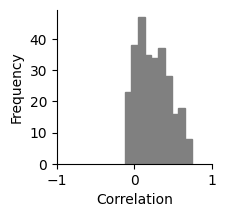

In [4]:
lambda_ridge = 0.1
kf = KFold(n_splits=5, shuffle=False)

results = {}
fold = 1
for train_idx, test_idx in kf.split(perturbations):
    train_pert = perturbations[train_idx]
    test_pert  = perturbations[test_idx]
    Ytrain_df = Y[train_pert]            
    Ytest_df  = Y[test_pert]              
    P_train_df = P.loc[train_pert]        
    P_test_df  = P.loc[test_pert]        

    # Train
    W, b, G, P_ = tfp.train_W(Ytrain_df, P_train_df, lambda_ridge=lambda_ridge)

    # Predict
    Y_hat = tfp.predict_withW(G, W, P_test_df, b) 

    pred_df = pd.DataFrame(Y_hat, index=Y.index, columns=test_pert)
    results[f"fold_{fold}"] = pred_df
    correlations = []
    for i, pert in enumerate(test_pert):
        y_true = Ytest_df.iloc[:, i].to_numpy()
        y_pred = Y_hat[:, i]
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        if mask.sum() > 1:
            r, _ = stats.pearsonr(y_true[mask], y_pred[mask])
            correlations.append(r)
        else:
            correlations.append(np.nan)
    results[f"fold_{fold}_corr"] = pd.Series(correlations, index=test_pert)
    fold += 1
all_corrs = pd.DataFrame()
for k, v in results.items():
    if k.endswith("_corr"):
        all_corrs = pd.concat([all_corrs, v], axis=0)

# Plotting the distribution of correlations
fig, ax = plt.subplots(figsize=(2, 2))
ax.hist(all_corrs[0], edgecolor='gray',color='gray')
sns.despine() 
ax.set_xlabel('Correlation')
ax.set_ylabel('Frequency')
ax.set_xlim(-1, 1)
ax.set_xticks([-1,0,1])
ax.grid(False)
plt.show()